# Cicuitos dinámicos

long range CNOT gate teleportation using dynamic circuits

## Paso 1: mapear el problema a circuitos y operadores

In [22]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr

def get_dynamic_CNOT_circuit(num_qubits):
    """
    Supuestos:
    (1) 1D chain of nearest neighbors, 
    (2) 0th qbit is the control, and the last qbit is the target
    (3) the control qubit starts in the |+> state

    """
    num_ancilla = num_qubits - 2
    num_ancilla_pairs = int(num_ancilla/ 2)

    qr = QuantumRegister(num_qubits)
    cr1 = ClassicalRegister(num_ancilla_pairs,name='cr1') # The parityn-controlled X gate
    cr2 = ClassicalRegister(num_ancilla-num_ancilla_pairs,name='cr2') # The parity controlled Z gate
    cr3 = ClassicalRegister(2,name='cr3') #final meassurments control an target qbit
    qc = QuantumCircuit(qr,cr1,cr2,cr3)


    #iniciando el qubit de control
    qc.h(0)
    qc.barrier()


    # Entangle the control qubit and the first ancilla qubit
    qc.cx(0,1)
    
    # the first ancilla qbit in index 1
    for i in range(num_ancilla_pairs):
        qc.h(2+2*i)
        qc.cx(2+2*i,2+2*i+1)

    #prepare bell pairs on staggered and data qubits
    for i in range(num_ancilla_pairs+1):
        qc.cx(1+2*i, 1+2*i+1)

    for i in range(1,num_ancilla_pairs+2):
        qc.h(2*i-1)

    # Measurmement on alternating ancilla qubits startin with the first one
    # Keep track of the pariry for eventual conditional Z gate

    for i in range(1, num_ancilla_pairs+2):
        qc.measure(2*i-1,cr2[i-1])
        if i == 1:
            parity_control = expr.lift(cr2[i-1])
        else:
            parity_control = expr.bit_xor(cr2[i-1], parity_control)

    
    # Measurmement on alternating ancilla qubits startin with the first one
    # Keep track of the pariry for eventual conditional Z gate

    for i in range(num_ancilla_pairs):
        qc.measure(2*i + 2 ,cr1[i])
        if i == 0:
            parity_target = expr.lift(cr1[i])
        else:
            parity_target = expr.bit_xor(cr1[i], parity_target)
            
    with qc.if_test((parity_control)):
        qc.z(0)

    with qc.if_test((parity_target)):
        qc.x(-1)

    return qc

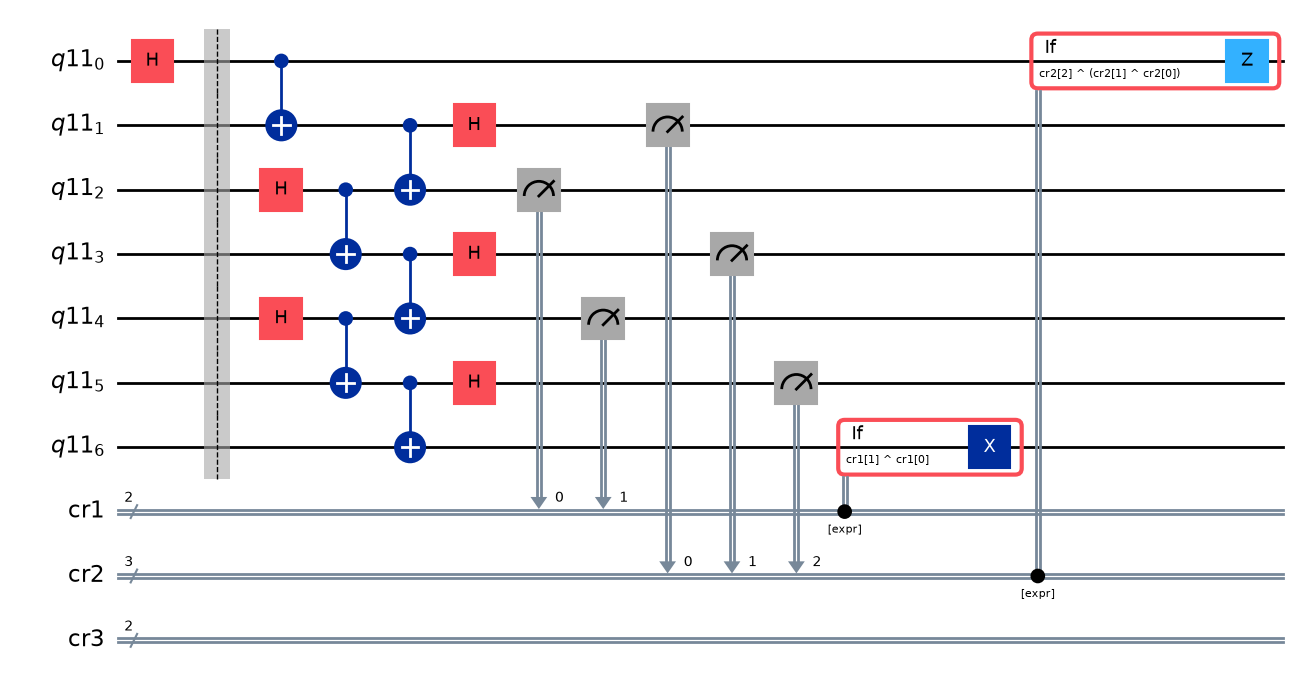

In [23]:
qc = get_dynamic_CNOT_circuit(num_qubits=7)
qc.draw('mpl')


In [24]:
max_num_qubits = 41
qc_list=[]
num_qubits_list= list(range(7,max_num_qubits,2))
for num_qubits in num_qubits_list:
    qc_list.append(get_dynamic_CNOT_circuit(num_qubits=num_qubits))


### Optimization for quantum execution


In [25]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
backend_name = "ibm_cusco"
service = QiskitRuntimeService()
backend = service.get_backend(backend_name)
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

qc_transpiled = pm.run(qc_list)

InvalidAccountError: 'Unable to retrieve instances. Please check that you are using a valid API token.'

# Step 3: execute the circuit

# Step 4: post-processing and plotting